# Single-substitution library design

Builds a pooled variant library for a protein whose coding sequence fits on one synthesis oligo (about 90 residues or fewer once adaptors are added). Edit the input cell, then run the cells in order. Files are written to a dated run directory under `out/`.

The QC plot uses matplotlib, which `uv sync` installs. Launch with `uv run --with jupyterlab jupyter lab`.

If the coding sequence is longer than one oligo, use `tiled-library-design.ipynb`.

## Input

Set your protein and options here. The rest of the notebook runs without changes.

In [1]:
from library_designer import LibrarySpec, CodonOptimizationParams, SubstitutionScan

# ===== EDIT: your protein and options =====
spec = LibrarySpec(
    name="my_library",
    protein_sequence="AEGNTLISVDYEIFGKVQGVFFRKHTQAEGKKLGLVGWVQNTDRGTVQGQLQGPISKVRHMQEWLETRGSPKSHIDKANFNNEKVILKLDYSDFQIVK",   # your protein, one-letter, no stop codon
    substitutions=["A", "P"],            # ["A"] alanine scan; list("ACDEFGHIKLMNPQRSTVWY") for full DMS; add "TAG" for an amber/stop scan
    adaptor_5="",                   # sequence added to the 5' end of every oligo (cloning or primer sites); leave empty for none
    adaptor_3="",                   # sequence added to the 3' end
    optimization=CodonOptimizationParams(species="e_coli", method="use_best_codon"),
    
    platform="twist_oligo_pools",   # "pooled", "arrayed", or a synthesis-methods method slug
    
    max_oligo_length=None,          # set to your synthesis length limit to flag constructs that run over
    seed=0,
)
spec

name,my_library
protein,98 aa AEGNTLISVDYE...LKLDYSDFQIVK
substitutions,A P
adaptors,5' 3'
avoid,BsaI + 2 motif pattern(s)
optimization,"e_coli, use_best_codon, iters=100000"
platform,twist_oligo_pools
max_oligo_length,","
seed,0


## Build

`generate()` lists every variant. `codon_optimize()` reverse-translates the wild-type protein once into a reference sequence, then changes only the mutated codon in each variant, so variants differ from wild type at one position and nowhere else. A variant whose codon cannot avoid a restricted motif is recorded in `lib.failed`.

In [2]:
lib = SubstitutionScan(spec).generate().codon_optimize()
print(len(lib), "variants")
if lib.failed:
    print(len(lib.failed), "could not be built:", lib.failed)
lib.df[["name", "wt_residue", "position", "mut_residue"]].head(8)

192 variants


,name,wt_residue,position,mut_residue
0,A1P,A,1,P
1,E2A,E,2,A
2,E2P,E,2,P
3,G3A,G,3,A
4,G3P,G,3,P
5,N4A,N,4,A
6,N4P,N,4,P
7,T5A,T,5,A


## Check

QC translates each variant back to protein and scans the variable region for restriction sites and forbidden motifs. `PASS` means every variant is clean; anything listed is a variant to review.

With a `starting_vector` set it goes further and simulates the cloning: cut the oligo, cut the destination vector, ligate, then align the product against the parent plasmid to confirm the only difference is the intended codon.

In [3]:
print(lib.summary())

Library 'my_library': 192 variants (192 optimized, 0 failed)
  platform: twist_oligo_pools
  sublibraries: P=96, A=95, WT=1
  adaptors: 5' '' (0 bp), 3' '' (0 bp), construct 294-294 bp
  optimization: species=e_coli, method=use_best_codon, gc=(None, None), iters=100000
  QC report: 192 variants, PASS
    translation round-trip: 192/192 ok
    BsaI site: no hit(s)
    motif /GGAGG.{8,12}[AG]TG/: no hit(s)
    motif /AGGAG.{8,12}ATG/: no hit(s)


## Codon-usage QC

Relative codon adaptiveness along the sequence. The grey line is the wild-type backbone; each point is a variant's stamped codon. Points near 1.0 use the preferred codon; lower points are synonymous codons chosen to avoid a motif. A pinned stop (amber) sits low by design.

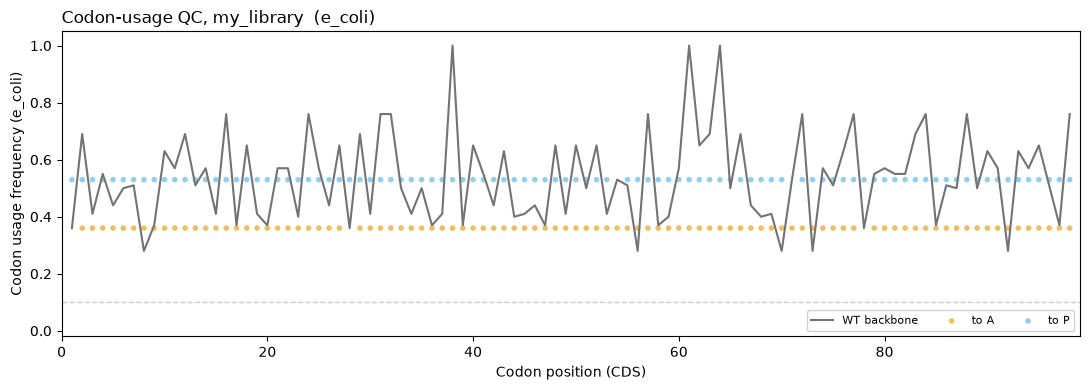

In [4]:
lib.plot_codon_usage()

## Export

Drops any variant that failed to build, then writes every output file: the master CSV, the uSort-M `variants.csv`, the vendor order form, the design specs, and the codon-usage QC plot.

Each run gets its own dated directory under `out/`, named after the moment the sequences were built. Re-running the notebook cannot overwrite an order you already sent, and any file you find later can be traced back to the run that made it. The path is on `lib.output_dir`, and the same stamp is recorded as `created` in the design specs.

In [ ]:
if lib.failed:
    lib.drop_failed()

lib.export_all("out")

import os
print("wrote to", lib.output_dir)
for f in sorted(os.listdir(lib.output_dir)):
    print("  ", f)

## Notes

- `substitutions` takes amino-acid letters (the optimizer picks the codon) or literal codons like `"TAG"`, placed as written. The variant name uses the translated residue, so an amber stop reads as `K7*`.
- `adaptor_5` and `adaptor_3` are added to every oligo and can hold cloning or primer sites. QC checks only the variable region between them.
- Set `max_oligo_length` to your synthesis limit to flag any construct that runs over it.